# **1) IMPORTS + CONFIGURACIÓN GLOBAL**

In [1]:
import os
import time
import math
import json
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms
from torchvision.datasets import ImageFolder

import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    f1_score,
    precision_score,
    confusion_matrix,
    classification_report,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

## 1.1) IDENTIDAD DEL EXPERIMENTO

In [2]:
EXPERIMENT_NAME = "MS_HQCNN"
MODEL_NAME = "MS-HQCNN-3"

## 1.2) SEMILLA

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
torch.set_default_dtype(torch.float32)

## 1.3) DISPOSITIVO

In [4]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
PL_TORCH_DEVICE = "cuda" if DEVICE.type == "cuda" else "cpu"

print("=" * 70)
print(f"[Experimento] {EXPERIMENT_NAME}")
print(f"[Modelo]      {MODEL_NAME}")
print("=" * 70)
print("[Device] Using:", DEVICE)
print("[PennyLane torch_device]:", PL_TORCH_DEVICE)
print("[CUDA available]:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("[CUDA device]:", torch.cuda.get_device_name(0))

[Experimento] MS_HQCNN
[Modelo]      MS-HQCNN-3
[Device] Using: cuda:0
[PennyLane torch_device]: cuda
[CUDA available]: True
[CUDA device]: NVIDIA GeForce RTX 3090


## 1.4) RUTA DEL DATASET

In [5]:
DATA_ROOT = r"C:\Users\lapic\datasets\Curated_XRay_256x256"

if not os.path.isdir(DATA_ROOT):
    raise FileNotFoundError(f"No encontré DATA_ROOT:\n{DATA_ROOT}")

print("[DATA_ROOT]", DATA_ROOT)

[DATA_ROOT] C:\Users\lapic\datasets\Curated_XRay_256x256


## 1.5) HIPERPARÁMETROS

In [6]:
IMG_SIZE = 256
IN_CHANNELS = 1

BATCH_SIZE = 16
NUM_WORKERS = 0

FRAC_TRAIN = 0.80
FRAC_VAL = 0.10

EPOCHS = 20

LATENT_DIM = 15
DROPOUT_P = 0.20

LR_Q = 3e-4
LR_CL = 1e-3
WEIGHT_DECAY = 1e-5

QUBITS = 4
LAYERS = 2
SHOTS = None
DIFF_METHOD = "backprop"

# Clave de velocidad: QNode batched por chunks grandes
CHUNK_PATCHES = 131072

## 1.6) CLASIFICADOR AUXILIAR

In [7]:
AUX_CLASSIFIER = "mlp"
AUX_MLP_HIDDEN = (32, 16)
AUX_MAX_ITER = 2000
AUX_RANDOM_STATE = SEED

## 1.7) CARPETAS DE RESULTADOS

In [8]:
RESULTS_ROOT = "Results"
MODEL_RESULTS_DIR = os.path.join(RESULTS_ROOT, EXPERIMENT_NAME)

CKPT_DIR = os.path.join(MODEL_RESULTS_DIR, "checkpoints")
EMB_DIR = os.path.join(MODEL_RESULTS_DIR, "embeddings")
FIG_DIR = os.path.join(MODEL_RESULTS_DIR, "figures")
LOG_DIR = os.path.join(MODEL_RESULTS_DIR, "logs")
TABLE_DIR = os.path.join(MODEL_RESULTS_DIR, "tables")

for d in [
    RESULTS_ROOT,
    MODEL_RESULTS_DIR,
    CKPT_DIR,
    EMB_DIR,
    FIG_DIR,
    LOG_DIR,
    TABLE_DIR,
]:
    os.makedirs(d, exist_ok=True)

## 1.8) RESUMEN

In [9]:
print("\n" + "=" * 70)
print("[Resumen]")
print("=" * 70)
print("IMG_SIZE          =", IMG_SIZE)
print("IN_CHANNELS       =", IN_CHANNELS)
print("BATCH_SIZE        =", BATCH_SIZE)
print("NUM_WORKERS       =", NUM_WORKERS)
print("EPOCHS            =", EPOCHS)
print("LATENT_DIM        =", LATENT_DIM)
print("QUBITS            =", QUBITS)
print("LAYERS            =", LAYERS)
print("SHOTS             =", SHOTS)
print("DIFF_METHOD       =", DIFF_METHOD)
print("CHUNK_PATCHES     =", CHUNK_PATCHES)
print("LR_Q              =", LR_Q)
print("LR_CL             =", LR_CL)
print("WEIGHT_DECAY      =", WEIGHT_DECAY)
print("DROPOUT_P         =", DROPOUT_P)
print("RESULTS_ROOT      =", RESULTS_ROOT)
print("MODEL_RESULTS_DIR =", MODEL_RESULTS_DIR)
print("CKPT_DIR          =", CKPT_DIR)
print("EMB_DIR           =", EMB_DIR)
print("FIG_DIR           =", FIG_DIR)
print("LOG_DIR           =", LOG_DIR)
print("TABLE_DIR         =", TABLE_DIR)
print("=" * 70)


[Resumen]
IMG_SIZE          = 256
IN_CHANNELS       = 1
BATCH_SIZE        = 16
NUM_WORKERS       = 0
EPOCHS            = 20
LATENT_DIM        = 15
QUBITS            = 4
LAYERS            = 2
SHOTS             = None
DIFF_METHOD       = backprop
CHUNK_PATCHES     = 131072
LR_Q              = 0.0003
LR_CL             = 0.001
WEIGHT_DECAY      = 1e-05
DROPOUT_P         = 0.2
RESULTS_ROOT      = Results
MODEL_RESULTS_DIR = Results\MS_HQCNN
CKPT_DIR          = Results\MS_HQCNN\checkpoints
EMB_DIR           = Results\MS_HQCNN\embeddings
FIG_DIR           = Results\MS_HQCNN\figures
LOG_DIR           = Results\MS_HQCNN\logs
TABLE_DIR         = Results\MS_HQCNN\tables


# **2) DATASET + TRANSFORMS + SPLITS + DATALOADERS**

## 2.1) Transformaciones

In [10]:
train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

eval_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

## 2.2) Cargar dataset completo

In [11]:
base_ds = ImageFolder(root=DATA_ROOT, transform=None)

print("=" * 70)
print("[Dataset completo]")
print("=" * 70)
print("Clases encontradas:", base_ds.classes)
print("class_to_idx:", base_ds.class_to_idx)
print("Total imágenes:", len(base_ds))

[Dataset completo]
Clases encontradas: ['COVID-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']
class_to_idx: {'COVID-19': 0, 'Normal': 1, 'Pneumonia-Bacterial': 2, 'Pneumonia-Viral': 3}
Total imágenes: 9209


## 2.3) Seleccionar clases: COVID vs Normal

In [12]:
POSITIVE_CLASS_CANDIDATES = ["COVID-19", "COVID", "Covid", "covid", "COVID19"]
NEGATIVE_CLASS_CANDIDATES = ["Normal", "NORMAL", "normal"]

def find_class_name(candidates, available_classes):
    for c in candidates:
        if c in available_classes:
            return c
    raise ValueError(f"No encontré ninguna clase de {candidates} en {available_classes}")

positive_class = find_class_name(POSITIVE_CLASS_CANDIDATES, base_ds.classes)
negative_class = find_class_name(NEGATIVE_CLASS_CANDIDATES, base_ds.classes)

positive_idx = base_ds.class_to_idx[positive_class]
negative_idx = base_ds.class_to_idx[negative_class]

print("\n[Clasificación binaria]")
print(f"Clase positiva y=1: {positive_class} | idx original={positive_idx}")
print(f"Clase negativa y=0: {negative_class} | idx original={negative_idx}")


[Clasificación binaria]
Clase positiva y=1: COVID-19 | idx original=0
Clase negativa y=0: Normal | idx original=1


## 2.4) Dataset binario

In [13]:
class BinaryImageFolder(Dataset):
    def __init__(self, base_ds, positive_idx, negative_idx, transform=None):
        self.base_ds = base_ds
        self.positive_idx = positive_idx
        self.negative_idx = negative_idx
        self.transform = transform

        self.samples = []

        for path, y_original in self.base_ds.samples:
            if y_original == positive_idx:
                self.samples.append((path, 1))
            elif y_original == negative_idx:
                self.samples.append((path, 0))

        if len(self.samples) == 0:
            raise RuntimeError("No se encontraron imágenes para las clases seleccionadas.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, y = self.samples[idx]

        img = self.base_ds.loader(path)

        if self.transform is not None:
            img = self.transform(img)

        y = torch.tensor(y, dtype=torch.float32)

        return img, y


binary_ds = BinaryImageFolder(
    base_ds=base_ds,
    positive_idx=positive_idx,
    negative_idx=negative_idx,
    transform=train_tfms,
)

labels_all = np.array([y for _, y in binary_ds.samples]).astype(int)

n_total = len(labels_all)
n_pos = int(labels_all.sum())
n_neg = int(n_total - n_pos)

print("\n[Dataset binario]")
print("Total:", n_total)
print(f"Negativos y=0 ({negative_class}):", n_neg)
print(f"Positivos y=1 ({positive_class}):", n_pos)
print(f"Proporción positivos: {100*n_pos/n_total:.2f}%")


[Dataset binario]
Total: 4552
Negativos y=0 (Normal): 3271
Positivos y=1 (COVID-19): 1281
Proporción positivos: 28.14%


## 2.5) Split estratificado train / val / test

In [14]:
indices = np.arange(len(binary_ds))
targets = labels_all

idx_train, idx_tmp, y_train_split, y_tmp = train_test_split(
    indices,
    targets,
    train_size=FRAC_TRAIN,
    random_state=SEED,
    stratify=targets,
)

val_fraction_of_tmp = FRAC_VAL / (1.0 - FRAC_TRAIN)

idx_val, idx_test, y_val_split, y_test_split = train_test_split(
    idx_tmp,
    y_tmp,
    train_size=val_fraction_of_tmp,
    random_state=SEED,
    stratify=y_tmp,
)

train_ds = Subset(binary_ds, idx_train)
val_ds   = Subset(binary_ds, idx_val)
test_ds  = Subset(binary_ds, idx_test)


def split_report(name, idxs):
    ys = labels_all[idxs].astype(int)
    total = len(ys)
    pos = int(ys.sum())
    neg = total - pos

    print(
        f"{name:>5}: total={total:5d} | "
        f"y=0 {neg:5d} | y=1 {pos:5d} | "
        f"pos={100*pos/total:5.2f}%"
    )

print("\n[Splits]")
split_report("train", idx_train)
split_report("val", idx_val)
split_report("test", idx_test)


[Splits]
train: total= 3641 | y=0  2616 | y=1  1025 | pos=28.15%
  val: total=  455 | y=0   327 | y=1   128 | pos=28.13%
 test: total=  456 | y=0   328 | y=1   128 | pos=28.07%


## 2.6) DataLoaders

In [15]:
g_cpu = torch.Generator(device="cpu")
g_cpu.manual_seed(SEED)

loader_kwargs_train = dict(
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g_cpu,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

loader_kwargs_eval = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

if NUM_WORKERS > 0:
    loader_kwargs_train["persistent_workers"] = True
    loader_kwargs_eval["persistent_workers"] = True
    loader_kwargs_train["prefetch_factor"] = 2
    loader_kwargs_eval["prefetch_factor"] = 2

train_loader = DataLoader(train_ds, **loader_kwargs_train)
val_loader   = DataLoader(val_ds, **loader_kwargs_eval)
test_loader  = DataLoader(test_ds, **loader_kwargs_eval)

print("\n[DataLoaders]")
print(f"NUM_WORKERS   = {NUM_WORKERS}")
print(f"BATCH_SIZE    = {BATCH_SIZE}")
print(f"Train batches = {len(train_loader)}")
print(f"Val batches   = {len(val_loader)}")
print(f"Test batches  = {len(test_loader)}")


[DataLoaders]
NUM_WORKERS   = 0
BATCH_SIZE    = 16
Train batches = 228
Val batches   = 29
Test batches  = 29


## 2.7) Sanity check de datos

In [16]:
xb, yb = next(iter(train_loader))

print("\n[Sanity batch]")
print("x shape:", xb.shape)
print("y shape:", yb.shape)
print("x dtype:", xb.dtype)
print("y dtype:", yb.dtype)
print("x min/max:", float(xb.min()), float(xb.max()))
print("y unique:", torch.unique(yb))


[Sanity batch]
x shape: torch.Size([16, 1, 256, 256])
y shape: torch.Size([16])
x dtype: torch.float32
y dtype: torch.float32
x min/max: -1.0 1.0
y unique: tensor([0., 1.])


## 2.8) Visualización rápida

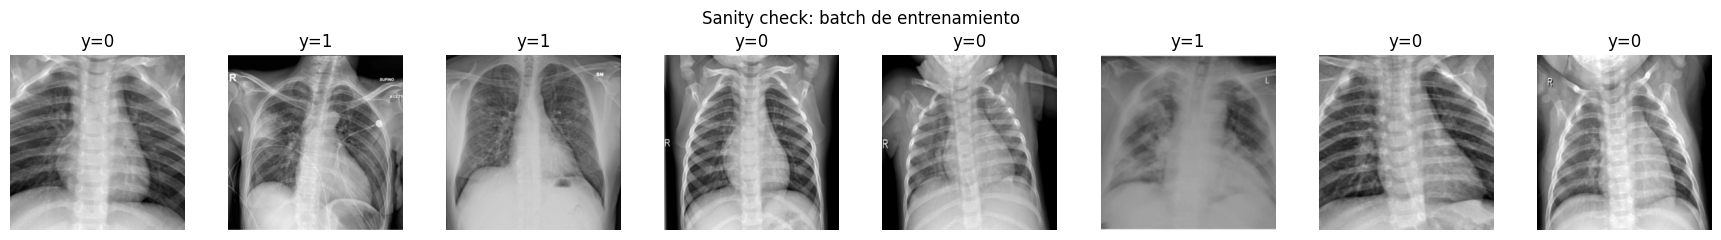

In [17]:
n_show = min(8, xb.shape[0])

fig, axes = plt.subplots(1, n_show, figsize=(2.2*n_show, 2.4))

if n_show == 1:
    axes = [axes]

for i in range(n_show):
    img = xb[i, 0].detach().cpu().numpy()
    label = int(yb[i].item())

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"y={label}")
    axes[i].axis("off")

plt.suptitle("Sanity check: batch de entrenamiento")
plt.tight_layout()
plt.show()

# **3) MÉTRICAS + CHECKPOINTS + GRÁFICAS**

## 3.1) UTILIDADES GENERALES

In [18]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def clone_state_dict_cpu(model):
    return {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }


def sigmoid_np(logits):
    return 1.0 / (1.0 + np.exp(-logits))

## 3.2) MÉTRICAS BINARIAS

In [19]:
def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, y_score)


def safe_pr_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return average_precision_score(y_true, y_score)


def binary_metrics_from_probs(
    y_true,
    probs,
    threshold=0.5
):

    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs).astype(float)

    y_pred = (probs >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn + 1e-12)
    specificity = tn / (tn + fp + 1e-12)

    bacc = 0.5 * (sensitivity + specificity)

    return {
        "threshold": float(threshold),
        "acc": float(acc),
        "f1": float(f1),
        "precision": float(prec),
        "bacc": float(bacc),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "pred1": float(y_pred.mean()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

## 3.3) BÚSQUEDA DE THRESHOLD ÓPTIMO

In [20]:
def find_best_threshold(
    y_true,
    probs,
    metric="bacc"
):

    probs = np.asarray(probs).astype(float)

    thresholds = np.unique(probs)

    if len(thresholds) > 1000:
        thresholds = np.linspace(
            0.0,
            1.0,
            1001
        )

    best_thr = 0.5
    best_val = -np.inf
    best_metrics = None

    for thr in thresholds:

        m = binary_metrics_from_probs(
            y_true,
            probs,
            threshold=thr
        )

        val = m[metric]

        if val > best_val:
            best_val = val
            best_thr = float(thr)
            best_metrics = m

    return best_thr, best_metrics

## 3.4) EVALUACIÓN COMPLETA

In [21]:
def evaluate_binary_outputs(
    y_true,
    logits_or_probs,
    from_logits=True
):

    y_true = np.asarray(y_true).astype(int)

    scores = np.asarray(
        logits_or_probs
    ).astype(float)

    if from_logits:
        probs = sigmoid_np(scores)
    else:
        probs = scores

    auc = safe_auc(
        y_true,
        probs
    )

    pr_auc = safe_pr_auc(
        y_true,
        probs
    )

    m05 = binary_metrics_from_probs(
        y_true,
        probs,
        threshold=0.5
    )

    thr_star, mstar = find_best_threshold(
        y_true,
        probs,
        metric="bacc"
    )

    return {
        "auc": float(auc),
        "pr_auc": float(pr_auc),
        "probs": probs,
        "m05": m05,
        "thr_star": float(thr_star),
        "mstar": mstar,
    }

## 3.5) FORMATO DE IMPRESIÓN POR ÉPOCA

In [22]:
def format_epoch_line(
    epoch,
    dt,
    train_loss,
    train_acc05,
    val_loss,
    val_eval,
    lr_q,
    lr_cl
):

    m05 = val_eval["m05"]
    ms = val_eval["mstar"]

    return (
        f"Época {epoch:02d} (dt={dt:.1f}s) | "
        f"Train loss={train_loss:.4f} "
        f"acc@0.5={100*train_acc05:.1f}% | "
        f"Val loss={val_loss:.4f} "
        f"AUC={val_eval['auc']:.3f} "
        f"PR-AUC={val_eval['pr_auc']:.3f} | "
        f"@0.5 acc={100*m05['acc']:.1f}% "
        f"F1={m05['f1']:.3f} "
        f"bAcc={m05['bacc']:.3f} "
        f"pred1={100*m05['pred1']:.1f}% | "
        f"@thr* acc={100*ms['acc']:.1f}% "
        f"F1={ms['f1']:.3f} "
        f"bAcc={ms['bacc']:.3f} "
        f"pred1={100*ms['pred1']:.1f}% "
        f"thr={val_eval['thr_star']:.3f} | "
        f"LR_Q={lr_q:.2e} | "
        f"LR_CL={lr_cl:.2e}"
    )

## 3.6) CHECKPOINTS

In [23]:
def save_checkpoint(
    path,
    model,
    optimizer,
    epoch,
    metrics,
    threshold=None
):

    payload = {
        "experiment_name": EXPERIMENT_NAME,
        "model_name": MODEL_NAME,
        "epoch": epoch,
        "model_state_dict": clone_state_dict_cpu(model),
        "optimizer_state_dict":
            optimizer.state_dict()
            if optimizer is not None
            else None,
        "metrics": metrics,
        "threshold": threshold,
    }

    torch.save(payload, path)


def load_model_state_from_checkpoint(
    model,
    path,
    map_location=DEVICE
):

    ckpt = torch.load(
        path,
        map_location=map_location
    )

    model.load_state_dict(
        ckpt["model_state_dict"]
    )

    return ckpt

## 3.7) GRÁFICAS DE ENTRENAMIENTO

In [24]:
def plot_history(
    history,
    fig_dir=FIG_DIR,
    prefix="fase1"
):

    df = pd.DataFrame(history)

    if len(df) == 0:
        return

    # --------------------------
    # LOSS
    # --------------------------

    plt.figure(figsize=(7,5))

    plt.plot(
        df["epoch"],
        df["train_loss"],
        marker="o",
        label="Train"
    )

    plt.plot(
        df["epoch"],
        df["val_loss"],
        marker="o",
        label="Val"
    )

    plt.title(f"{MODEL_NAME} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            fig_dir,
            f"{prefix}_loss.png"
        ),
        dpi=160
    )

    plt.show()

    # --------------------------
    # ACCURACY
    # --------------------------

    plt.figure(figsize=(7,5))

    plt.plot(
        df["epoch"],
        100*df["train_acc05"],
        marker="o",
        label="Train"
    )

    plt.plot(
        df["epoch"],
        100*df["val_acc05"],
        marker="o",
        label="Val @0.5"
    )

    plt.plot(
        df["epoch"],
        100*df["val_acc_thr"],
        marker="o",
        label="Val @thr*"
    )

    plt.title(f"{MODEL_NAME} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            fig_dir,
            f"{prefix}_accuracy.png"
        ),
        dpi=160
    )

    plt.show()

## 3.8) CURVAS ROC / PR Y MATRIZ DE CONFUSIÓN

In [25]:
def plot_eval_curves(
    y_true,
    probs,
    threshold,
    split_name="test",
    fig_dir=FIG_DIR,
    prefix="fase1"
):

    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs).astype(float)

    if len(np.unique(y_true)) == 2:

        fpr, tpr, _ = roc_curve(
            y_true,
            probs
        )

        auc = roc_auc_score(
            y_true,
            probs
        )

        plt.figure(figsize=(6,5))

        plt.plot(
            fpr,
            tpr,
            label=f"AUC={auc:.3f}"
        )

        plt.plot(
            [0,1],
            [0,1],
            "--"
        )

        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title(f"ROC - {split_name}")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

## 3.9) GUARDAR CONFIGURACIÓN

In [26]:
config_path = os.path.join(
    LOG_DIR,
    "config.json"
)

config_dict = {
    "experiment_name": EXPERIMENT_NAME,
    "model_name": MODEL_NAME,
    "seed": SEED,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "latent_dim": LATENT_DIM,
    "qubits": QUBITS,
    "layers": LAYERS,
    "chunk_patches": CHUNK_PATCHES,
}

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        config_dict,
        f,
        indent=2,
        ensure_ascii=False
    )

print("=" * 70)
print("[OK] Sección 3 lista")
print("Config:", config_path)
print("=" * 70)

[OK] Sección 3 lista
Config: Results\MS_HQCNN\logs\config.json


# **4) BACKEND CUÁNTICO RÁPIDO + QUANVOLUTION NORMAL/GRUPAL**

## 4.1) DISPOSITIVO PENNYLANE

In [27]:
qdev = qml.device(
    "default.qubit.torch",
    wires=QUBITS,
    shots=SHOTS,
    torch_device=PL_TORCH_DEVICE
)

print("=" * 70)
print("[Sección 4] Backend cuántico")
print("=" * 70)
print("PennyLane device :", qdev)
print("PL_TORCH_DEVICE  :", PL_TORCH_DEVICE)
print("QUBITS           :", QUBITS)
print("LAYERS           :", LAYERS)
print("SHOTS            :", SHOTS)
print("DIFF_METHOD      :", DIFF_METHOD)
print("CHUNK_PATCHES    :", CHUNK_PATCHES)

[Sección 4] Backend cuántico
PennyLane device : Default qubit (Torch) PennyLane plugin
Short name: default.qubit.torch
Package: pennylane
Plugin version: 0.37.0
Author: Xanadu Inc.
Wires: 4
Shots: None
PL_TORCH_DEVICE  : cuda
QUBITS           : 4
LAYERS           : 2
SHOTS            : None
DIFF_METHOD      : backprop
CHUNK_PATCHES    : 131072


## 4.2) QNODE BATCHED RÁPIDO

In [28]:
@qml.qnode(
    qdev,
    interface="torch",
    diff_method=DIFF_METHOD
)
def quanv_circuit_batched_fixed4(
    angles_b,
    weights
):
    """
    angles_b : (N, 4)
    weights  : (LAYERS, 4, 2)

    Regresa:
        tuple de 4 tensores, cada uno de forma (N,)
    """

    # ----------------------------
    # Encoding
    # ----------------------------
    for w in range(4):
        qml.RY(
            angles_b[:, w],
            wires=w
        )

    # ----------------------------
    # Ansatz variacional
    # ----------------------------
    for l in range(LAYERS):

        for w in range(4):
            qml.RY(
                weights[l, w, 0],
                wires=w
            )
            qml.RZ(
                weights[l, w, 1],
                wires=w
            )

        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[1, 2])
        qml.CNOT(wires=[2, 3])
        qml.CNOT(wires=[3, 0])

    return (
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliZ(1)),
        qml.expval(qml.PauliZ(2)),
        qml.expval(qml.PauliZ(3)),
    )

## 4.3) QUANVOLUTION NORMAL
      Para entrada de 1 canal:
      B×1×H×W -> B×4×H/2×W/2

In [29]:
class Quanv2x2Stride2_1ch(nn.Module):

    def __init__(
        self,
        chunk_patches=CHUNK_PATCHES
    ):
        super().__init__()

        self.chunk = chunk_patches

        self.weights = nn.Parameter(
            0.1 * torch.randn(
                LAYERS,
                4,
                2,
                dtype=torch.float32
            )
        )

        self._dbg_printed = False

    def forward(
        self,
        x
    ):
        """
        x: (B, 1, H, W)

        salida:
            (B, 4, H/2, W/2)
        """

        x = x.to(dtype=torch.float32)

        B, C, H, W = x.shape

        assert C == 1, f"Quanv normal espera C=1, recibió C={C}"

        if (H % 2) or (W % 2):
            x = F.pad(
                x,
                (0, W % 2, 0, H % 2),
                value=0.0
            )
            B, C, H, W = x.shape

        H2 = H // 2
        W2 = W // 2

        # Patches 2x2 sin F.unfold para mantenerlo ligero
        # (B,1,H,W) -> (B,H/2,W/2,2,2)
        patches = x.view(
            B,
            1,
            H2,
            2,
            W2,
            2
        )

        patches = patches.permute(
            0,
            2,
            4,
            1,
            3,
            5
        ).contiguous()

        # (B,H2,W2,1,2,2) -> (B*H2*W2,4)
        patches = patches.reshape(
            B * H2 * W2,
            4
        )

        # En la HQCNN tuneada: ángulos directos desde los 4 pixeles
        angles = math.pi * patches

        outs = []

        N = angles.shape[0]

        for s in range(
            0,
            N,
            self.chunk
        ):

            e = min(
                s + self.chunk,
                N
            )

            out_chunk = quanv_circuit_batched_fixed4(
                angles[s:e],
                self.weights
            )

            # tuple(4 tensors (chunk,)) -> (chunk,4)
            out_chunk = torch.stack(
                out_chunk,
                dim=1
            )

            outs.append(out_chunk)

        out = torch.cat(
            outs,
            dim=0
        )

        out = out.view(
            B,
            H2,
            W2,
            4
        )

        out = out.permute(
            0,
            3,
            1,
            2
        ).contiguous()

        out = out.to(dtype=torch.float32)

        if not self._dbg_printed:
            print(
                f"[Quanv normal] "
                f"input=({B},{C},{H},{W}) -> output={tuple(out.shape)} | "
                f"chunk={self.chunk}"
            )
            self._dbg_printed = True

        return out

## 4.4) QUANVOLUTION GRUPAL

      Para feature maps multicanal:

      Entrada:
          B×C×H×W

      Se agrupan canales de g en g:
          ng = C/g

      Cada grupo:
          g canales × 2×2 = 4g valores
          Linear(4g -> 4)
          QNode de 4 qubits
          4 mediciones

      Salida:
          B×(4ng)×H/2×W/2

In [30]:
class GroupQuanv2x2Stride2(nn.Module):

    def __init__(
        self,
        in_channels,
        group_size=4,
        n_meas=4,
        chunk_patches=CHUNK_PATCHES
    ):
        super().__init__()

        assert in_channels % group_size == 0, (
            f"in_channels={in_channels} debe ser divisible por group_size={group_size}"
        )

        assert n_meas in [1, 2, 4], "n_meas debe ser 1, 2 o 4"

        self.in_channels = in_channels
        self.group_size = group_size
        self.n_groups = in_channels // group_size
        self.n_meas = n_meas
        self.chunk = chunk_patches

        self.proj = nn.Linear(
            4 * group_size,
            4
        )

        self.weights = nn.Parameter(
            0.1 * torch.randn(
                LAYERS,
                4,
                2,
                dtype=torch.float32
            )
        )

        self._dbg_printed = False

    def forward(
        self,
        x
    ):
        """
        x: (B, C, H, W)

        salida:
            (B, n_groups*n_meas, H/2, W/2)
        """

        x = x.to(dtype=torch.float32)

        B, C, H, W = x.shape

        assert C == self.in_channels, (
            f"Esperaba C={self.in_channels}, recibió C={C}"
        )

        if (H % 2) or (W % 2):
            x = F.pad(
                x,
                (0, W % 2, 0, H % 2),
                value=0.0
            )
            B, C, H, W = x.shape

        H2 = H // 2
        W2 = W // 2

        # ----------------------------------------------------
        # Reordenar a patches 2x2 por grupos de canales
        # ----------------------------------------------------

        # (B,C,H,W) -> (B,C,H2,2,W2,2)
        x = x.view(
            B,
            C,
            H2,
            2,
            W2,
            2
        )

        # (B,H2,W2,C,2,2)
        x = x.permute(
            0,
            2,
            4,
            1,
            3,
            5
        ).contiguous()

        # (B,H2,W2,n_groups,g,2,2)
        x = x.view(
            B,
            H2,
            W2,
            self.n_groups,
            self.group_size,
            2,
            2
        )

        # (B*H2*W2*n_groups, 4g)
        x = x.reshape(
            B * H2 * W2 * self.n_groups,
            self.group_size * 4
        )

        # ----------------------------------------------------
        # Proyección clásica 4g -> 4 ángulos
        # ----------------------------------------------------

        angles = self.proj(x)
        angles = torch.tanh(angles) * math.pi

        # ----------------------------------------------------
        # QNode batched por chunks
        # ----------------------------------------------------

        outs = []

        N = angles.shape[0]

        for s in range(
            0,
            N,
            self.chunk
        ):

            e = min(
                s + self.chunk,
                N
            )

            out_chunk = quanv_circuit_batched_fixed4(
                angles[s:e],
                self.weights
            )

            # tuple(4 tensors) -> (chunk,4)
            out_chunk = torch.stack(
                out_chunk,
                dim=1
            )

            if self.n_meas == 1:
                out_chunk = out_chunk[:, :1]
            elif self.n_meas == 2:
                out_chunk = out_chunk[:, :2]
            else:
                out_chunk = out_chunk[:, :4]

            outs.append(out_chunk)

        out = torch.cat(
            outs,
            dim=0
        )

        # ----------------------------------------------------
        # Reconstrucción espacial
        # ----------------------------------------------------

        out = out.view(
            B,
            H2,
            W2,
            self.n_groups * self.n_meas
        )

        out = out.permute(
            0,
            3,
            1,
            2
        ).contiguous()

        out = out.to(dtype=torch.float32)

        if not self._dbg_printed:
            print(
                f"[Quanv grupal] "
                f"Cin={self.in_channels}, g={self.group_size}, "
                f"ng={self.n_groups}, n_meas={self.n_meas} -> "
                f"Cout={self.n_groups*self.n_meas} | "
                f"output={tuple(out.shape)} | chunk={self.chunk}"
            )
            self._dbg_printed = True

        return out

## 4.5) SANITY CHECK LIGERO

In [31]:
print("\n" + "=" * 70)
print("[Sanity check Sección 4]")
print("=" * 70)

with torch.no_grad():

    # Quanv normal
    q_normal = Quanv2x2Stride2_1ch(
        chunk_patches=CHUNK_PATCHES
    ).to(DEVICE)

    x1 = torch.randn(
        1,
        1,
        32,
        32,
        device=DEVICE
    )

    y1 = q_normal(x1)

    print("Quanv normal:")
    print("input :", tuple(x1.shape))
    print("output:", tuple(y1.shape))

    del q_normal, x1, y1

    # Quanv grupal con C=16, g=4
    q_group = GroupQuanv2x2Stride2(
        in_channels=16,
        group_size=4,
        n_meas=4,
        chunk_patches=CHUNK_PATCHES
    ).to(DEVICE)

    xg = torch.randn(
        1,
        16,
        32,
        32,
        device=DEVICE
    )

    yg = q_group(xg)

    print("\nQuanv grupal:")
    print("input :", tuple(xg.shape))
    print("output:", tuple(yg.shape))

    del q_group, xg, yg

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n[OK] Sección 4 lista: backend cuántico batched rápido.")


[Sanity check Sección 4]
[Quanv normal] input=(1,1,32,32) -> output=(1, 4, 16, 16) | chunk=131072
Quanv normal:
input : (1, 1, 32, 32)
output: (1, 4, 16, 16)
[Quanv grupal] Cin=16, g=4, ng=4, n_meas=4 -> Cout=16 | output=(1, 16, 16, 16) | chunk=131072

Quanv grupal:
input : (1, 16, 32, 32)
output: (1, 16, 16, 16)

[OK] Sección 4 lista: backend cuántico batched rápido.


# **5) ARQUITECTURA MS-HQCNN-3**

## 5.1) BLOQUE DE MEZCLA CLÁSICA

In [32]:
class MixBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):
        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):
        return self.block(x)

## 5.2) ETAPA CUÁNTICA INICIAL
      1 canal -> Quanv normal -> mezcla

In [33]:
class QuantumStage1(nn.Module):

    def __init__(self):

        super().__init__()

        self.quanv = Quanv2x2Stride2_1ch(
            chunk_patches=CHUNK_PATCHES
        )

        self.mix = MixBlock(
            in_channels=4,
            out_channels=16
        )

    def forward(self, x):

        x = self.quanv(x)

        x = self.mix(x)

        return x

## 5.3) ETAPA CUÁNTICA INTERMEDIA
      Quanv grupal -> mezcla

In [34]:
class QuantumStageGrouped(nn.Module):

    def __init__(
        self,
        in_channels,
        group_size,
        mix_out_channels
    ):
        super().__init__()

        self.quanv = GroupQuanv2x2Stride2(
            in_channels=in_channels,
            group_size=group_size,
            n_meas=4,
            chunk_patches=CHUNK_PATCHES
        )

        q_out = (
            (in_channels // group_size)
            * 4
        )

        self.mix = MixBlock(
            in_channels=q_out,
            out_channels=mix_out_channels
        )

    def forward(self, x):

        x = self.quanv(x)

        x = self.mix(x)

        return x

## 5.4) MS-HQCNN-3

In [35]:
class MSHQCNN3(nn.Module):

    def __init__(
        self,
        latent_dim=15,
        dropout_p=0.20
    ):
        super().__init__()

        # ----------------------------------
        # Stage 1
        #
        # 1x256x256
        # -> 16x128x128
        # ----------------------------------

        self.stage1 = QuantumStage1()

        # ----------------------------------
        # Stage 2
        #
        # 16x128x128
        # -> 32x64x64
        # ----------------------------------

        self.stage2 = QuantumStageGrouped(
            in_channels=16,
            group_size=4,
            mix_out_channels=32
        )

        # ----------------------------------
        # Stage 3
        #
        # 32x64x64
        # -> 32x32x32
        # ----------------------------------

        self.stage3 = QuantumStageGrouped(
            in_channels=32,
            group_size=4,
            mix_out_channels=32
        )

        # ----------------------------------
        # Global Average Pooling
        # ----------------------------------

        self.gap = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        # ----------------------------------
        # Embedding z15
        # ----------------------------------

        self.latent = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                32,
                64
            ),

            nn.ReLU(inplace=True),

            nn.Dropout(
                dropout_p
            ),

            nn.Linear(
                64,
                latent_dim
            )

        )

        # ----------------------------------
        # Head propia
        # ----------------------------------

        self.head = nn.Linear(
            latent_dim,
            1
        )

    # --------------------------------------
    # EXTRACTOR
    # --------------------------------------

    def extract_features(self, x):

        x = self.stage1(x)

        x = self.stage2(x)

        x = self.stage3(x)

        x = self.gap(x)

        z15 = self.latent(x)

        return z15

    # --------------------------------------
    # FORWARD
    # --------------------------------------

    def forward(
        self,
        x,
        return_z=False
    ):

        z15 = self.extract_features(x)

        logits = self.head(
            z15
        ).squeeze(1)

        if return_z:
            return logits, z15

        return logits

## 5.5) CREAR MODELO

In [36]:
model = MSHQCNN3(
    latent_dim=LATENT_DIM,
    dropout_p=DROPOUT_P
).to(DEVICE)

total_params, trainable_params = count_parameters(
    model
)

print("=" * 70)
print("[MS-HQCNN-3]")
print("=" * 70)

print(
    f"Total params     : {total_params:,}"
)

print(
    f"Trainable params : {trainable_params:,}"
)

print("=" * 70)

[MS-HQCNN-3]
Total params     : 5,047
Trainable params : 5,047


## 5.6) SEPARAR PARÁMETROS

In [37]:
quantum_params = []
classical_params = []

for name, param in model.named_parameters():

    if not param.requires_grad:
        continue

    if "weights" in name:
        quantum_params.append(param)
    else:
        classical_params.append(param)

n_q = sum(
    p.numel()
    for p in quantum_params
)

n_c = sum(
    p.numel()
    for p in classical_params
)

print(
    f"Quantum params   : {n_q:,}"
)

print(
    f"Classical params : {n_c:,}"
)

Quantum params   : 48
Classical params : 4,999


## 5.7) OPTIMIZADOR

In [38]:
optimizer = torch.optim.AdamW(

    [
        {
            "params": quantum_params,
            "lr": LR_Q
        },

        {
            "params": classical_params,
            "lr": LR_CL,
            "weight_decay": WEIGHT_DECAY
        }
    ]

)

criterion = nn.BCEWithLogitsLoss()

print("\n[OK] Sección 5 lista.")


[OK] Sección 5 lista.


# **6) FASE 1: ENTRENAR RED COMPLETA**
    Imagen -> MS-HQCNN-3 -> z15 -> head propia

## 6.1) FUNCIONES TRAIN / EVAL

In [39]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0.0
    all_logits = []
    all_targets = []

    for xb, yb in loader:

        xb = xb.to(
            device,
            non_blocking=True
        ).float()

        yb = yb.to(
            device,
            non_blocking=True
        ).float()

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(xb)

        loss = criterion(
            logits,
            yb
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += (
            loss.item()
            * xb.size(0)
        )

        all_logits.append(
            logits.detach().cpu()
        )

        all_targets.append(
            yb.detach().cpu()
        )

    epoch_loss = running_loss / len(loader.dataset)

    all_logits = torch.cat(
        all_logits
    ).numpy()

    all_targets = torch.cat(
        all_targets
    ).numpy().astype(int)

    probs = sigmoid_np(
        all_logits
    )

    m05 = binary_metrics_from_probs(
        all_targets,
        probs,
        threshold=0.5
    )

    return epoch_loss, m05["acc"]


@torch.no_grad()
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    all_logits = []
    all_targets = []

    for xb, yb in loader:

        xb = xb.to(
            device,
            non_blocking=True
        ).float()

        yb = yb.to(
            device,
            non_blocking=True
        ).float()

        logits = model(xb)

        loss = criterion(
            logits,
            yb
        )

        running_loss += (
            loss.item()
            * xb.size(0)
        )

        all_logits.append(
            logits.detach().cpu()
        )

        all_targets.append(
            yb.detach().cpu()
        )

    epoch_loss = running_loss / len(loader.dataset)

    all_logits = torch.cat(
        all_logits
    ).numpy()

    all_targets = torch.cat(
        all_targets
    ).numpy().astype(int)

    eval_res = evaluate_binary_outputs(
        y_true=all_targets,
        logits_or_probs=all_logits,
        from_logits=True
    )

    eval_res["loss"] = float(epoch_loss)
    eval_res["targets"] = all_targets
    eval_res["logits"] = all_logits

    return epoch_loss, eval_res

## 6.2) CHECKPOINTS A MONITOREAR

In [40]:
history = []

best_ckpts = {

    "val_loss": {
        "score": np.inf,
        "path": os.path.join(
            CKPT_DIR,
            "best_val_loss.pt"
        )
    },

    "val_auc": {
        "score": -np.inf,
        "path": os.path.join(
            CKPT_DIR,
            "best_val_auc.pt"
        )
    },

    "val_bacc_thr": {
        "score": -np.inf,
        "path": os.path.join(
            CKPT_DIR,
            "best_val_bacc_thr.pt"
        )
    }
}

## 6.3) ENTRENAMIENTO PRINCIPAL

In [41]:
print("=" * 70)
print("[FASE 1] Entrenamiento red completa")
print("=" * 70)

global_t0 = time.time()

for epoch in range(
    1,
    EPOCHS + 1
):

    t0 = time.time()

    train_loss, train_acc05 = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE
    )

    val_loss, val_eval = evaluate_model(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    dt = time.time() - t0

    lr_q_now = optimizer.param_groups[0]["lr"]
    lr_cl_now = optimizer.param_groups[1]["lr"]

    print(
        format_epoch_line(
            epoch=epoch,
            dt=dt,
            train_loss=train_loss,
            train_acc05=train_acc05,
            val_loss=val_loss,
            val_eval=val_eval,
            lr_q=lr_q_now,
            lr_cl=lr_cl_now
        ),
        flush=True
    )

    row = {
        "epoch": epoch,
        "dt": dt,

        "train_loss": train_loss,
        "train_acc05": train_acc05,

        "val_loss": val_loss,
        "val_auc": val_eval["auc"],
        "val_pr_auc": val_eval["pr_auc"],

        "val_acc05": val_eval["m05"]["acc"],
        "val_f105": val_eval["m05"]["f1"],
        "val_bacc05": val_eval["m05"]["bacc"],
        "val_pred105": val_eval["m05"]["pred1"],

        "val_thr_star": val_eval["thr_star"],

        "val_acc_thr": val_eval["mstar"]["acc"],
        "val_f1_thr": val_eval["mstar"]["f1"],
        "val_bacc_thr": val_eval["mstar"]["bacc"],
        "val_pred1_thr": val_eval["mstar"]["pred1"],

        "lr_q": lr_q_now,
        "lr_cl": lr_cl_now,
    }

    history.append(row)

    metrics_for_ckpt = {
        k: float(v)
        for k, v in row.items()
        if isinstance(
            v,
            (int, float, np.integer, np.floating)
        )
    }

    # --------------------------------------------------------
    # Mejor val_loss
    # --------------------------------------------------------

    if val_loss < best_ckpts["val_loss"]["score"]:

        best_ckpts["val_loss"]["score"] = val_loss

        save_checkpoint(
            path=best_ckpts["val_loss"]["path"],
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            metrics=metrics_for_ckpt,
            threshold=val_eval["thr_star"]
        )

    # --------------------------------------------------------
    # Mejor val_auc
    # --------------------------------------------------------

    if val_eval["auc"] > best_ckpts["val_auc"]["score"]:

        best_ckpts["val_auc"]["score"] = val_eval["auc"]

        save_checkpoint(
            path=best_ckpts["val_auc"]["path"],
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            metrics=metrics_for_ckpt,
            threshold=val_eval["thr_star"]
        )

    # --------------------------------------------------------
    # Mejor val_bacc_thr
    # --------------------------------------------------------

    if val_eval["mstar"]["bacc"] > best_ckpts["val_bacc_thr"]["score"]:

        best_ckpts["val_bacc_thr"]["score"] = val_eval["mstar"]["bacc"]

        save_checkpoint(
            path=best_ckpts["val_bacc_thr"]["path"],
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            metrics=metrics_for_ckpt,
            threshold=val_eval["thr_star"]
        )

[FASE 1] Entrenamiento red completa
[Quanv normal] input=(16,1,256,256) -> output=(16, 4, 128, 128) | chunk=131072
[Quanv grupal] Cin=16, g=4, ng=4, n_meas=4 -> Cout=16 | output=(16, 16, 64, 64) | chunk=131072
[Quanv grupal] Cin=32, g=4, ng=8, n_meas=4 -> Cout=32 | output=(16, 32, 32, 32) | chunk=131072
Época 01 (dt=417.8s) | Train loss=0.3781 acc@0.5=83.2% | Val loss=0.2552 AUC=0.955 PR-AUC=0.925 | @0.5 acc=90.1% F1=0.796 bAcc=0.836 pred1=20.4% | @thr* acc=90.3% F1=0.844 bAcc=0.911 pred1=33.8% thr=0.064 | LR_Q=3.00e-04 | LR_CL=1.00e-03
Época 02 (dt=385.1s) | Train loss=0.2223 acc@0.5=92.2% | Val loss=0.1839 AUC=0.966 PR-AUC=0.942 | @0.5 acc=93.0% F1=0.872 bAcc=0.906 pred1=26.8% | @thr* acc=93.8% F1=0.895 bAcc=0.936 pred1=30.3% thr=0.289 | LR_Q=3.00e-04 | LR_CL=1.00e-03
Época 03 (dt=387.0s) | Train loss=0.1979 acc@0.5=93.4% | Val loss=0.1862 AUC=0.971 PR-AUC=0.945 | @0.5 acc=93.6% F1=0.880 bAcc=0.903 pred1=24.8% | @thr* acc=95.2% F1=0.914 bAcc=0.940 pred1=28.1% thr=0.208 | LR_Q=3.00e-0

## 6.4) GUARDAR HISTORIAL

In [42]:
total_time = time.time() - global_t0

history_df = pd.DataFrame(
    history
)

history_csv = os.path.join(
    LOG_DIR,
    "fase1_history.csv"
)

history_json = os.path.join(
    LOG_DIR,
    "fase1_history.json"
)

history_df.to_csv(
    history_csv,
    index=False
)

with open(
    history_json,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        history,
        f,
        indent=2,
        ensure_ascii=False
    )

## 6.5) RESUMEN FINAL

In [43]:
print("\n" + "=" * 70)
print("[FASE 1 terminada]")
print("=" * 70)

print(
    f"Tiempo total: {total_time/60:.2f} min"
)

print("\n[Mejores checkpoints]")

for key, info in best_ckpts.items():

    print(
        f"{key:15s} "
        f"score={info['score']:.5f} | "
        f"path={info['path']}"
    )

print("\n[Historial guardado]")
print(history_csv)
print(history_json)


[FASE 1 terminada]
Tiempo total: 150.64 min

[Mejores checkpoints]
val_loss        score=0.12093 | path=Results\MS_HQCNN\checkpoints\best_val_loss.pt
val_auc         score=0.98552 | path=Results\MS_HQCNN\checkpoints\best_val_auc.pt
val_bacc_thr    score=0.96518 | path=Results\MS_HQCNN\checkpoints\best_val_bacc_thr.pt

[Historial guardado]
Results\MS_HQCNN\logs\fase1_history.csv
Results\MS_HQCNN\logs\fase1_history.json


## 6.6) GRÁFICAS DE ENTRENAMIENTO

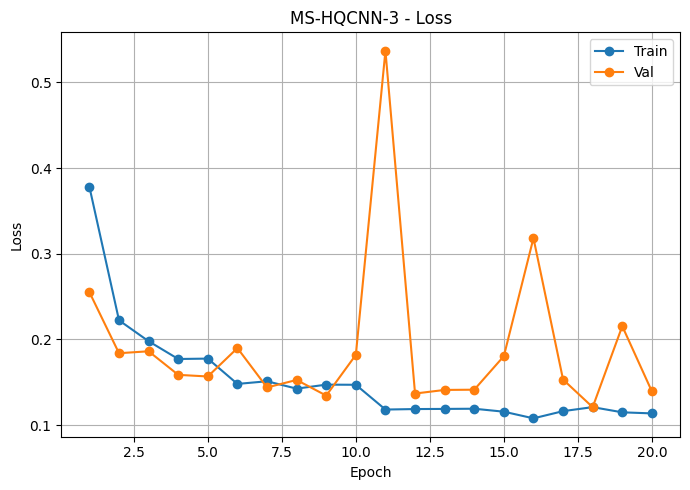

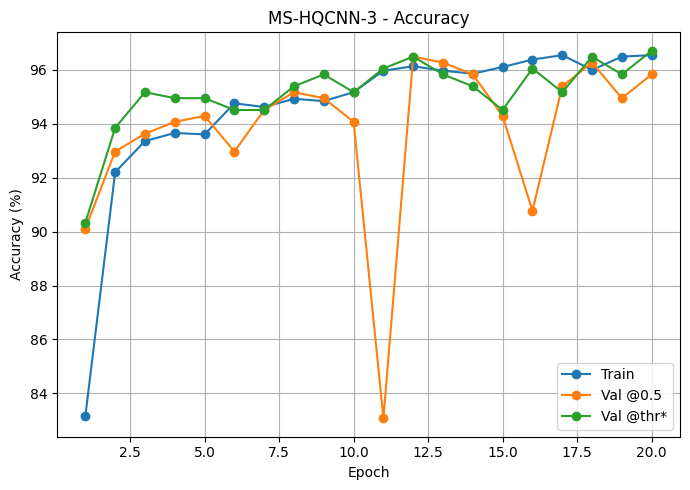

In [44]:
plot_history(
    history=history,
    fig_dir=FIG_DIR,
    prefix="fase1"
)

# **7) FASE 1: EVALUACIÓN FINAL EN TEST**
    Modelo completo: Imagen -> MS-HQCNN-3 -> z15 -> head propia

## 7.1) SELECCIONAR CHECKPOINT

In [45]:
BEST_CRITERION = "val_bacc_thr"   # opciones: "val_loss", "val_auc", "val_bacc_thr"

best_ckpt_path = best_ckpts[BEST_CRITERION]["path"]

print("=" * 70)
print("[FASE 1 - TEST] Evaluación final MS-HQCNN")
print("=" * 70)
print("Checkpoint seleccionado:", BEST_CRITERION)
print("Ruta:", best_ckpt_path)

[FASE 1 - TEST] Evaluación final MS-HQCNN
Checkpoint seleccionado: val_bacc_thr
Ruta: Results\MS_HQCNN\checkpoints\best_val_bacc_thr.pt


## 7.2) CARGAR MEJOR CHECKPOINT

In [46]:
ckpt = load_model_state_from_checkpoint(
    model=model,
    path=best_ckpt_path,
    map_location=DEVICE
)

best_epoch = ckpt["epoch"]
best_threshold = ckpt["threshold"]

print("\n[Checkpoint cargado]")
print("Época:", best_epoch)
print("Threshold guardado:", best_threshold)
print("Métricas val:", ckpt["metrics"])

C:\Users\lapic\AppData\Local\Temp\ipykernel_9288\1804029111.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(



[Checkpoint cargado]
Época: 20
Threshold guardado: 0.04674587302436954
Métricas val: {'epoch': 20.0, 'dt': 670.5742123126984, 'train_loss': 0.11367001660184542, 'train_acc05': 0.9653941224938204, 'val_loss': 0.13936740163672756, 'val_auc': 0.9831565366972477, 'val_pr_auc': 0.9791974171841983, 'val_acc05': 0.9582417582417583, 'val_f105': 0.9218106995884774, 'val_bacc05': 0.9329128440366923, 'val_pred105': 0.25274725274725274, 'val_thr_star': 0.04674587302436954, 'val_acc_thr': 0.967032967032967, 'val_f1_thr': 0.9425287356321839, 'val_bacc_thr': 0.9651782301223188, 'val_pred1_thr': 0.2923076923076923, 'lr_q': 0.0003, 'lr_cl': 0.001}


## 7.3) EVALUAR VALIDACIÓN Y TEST

In [48]:
val_loss_final, val_eval_final = evaluate_model(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=DEVICE
)

test_loss, test_eval = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE
)

y_test = test_eval["targets"]
p_test = test_eval["probs"]

m_test_05 = test_eval["m05"]
m_test_thr = binary_metrics_from_probs(
    y_true=y_test,
    probs=p_test,
    threshold=best_threshold
)

print("\n" + "=" * 70)
print("[RESULTADOS TEST - MS-HQCNN]")
print("=" * 70)

print(f"Test loss  : {test_loss:.4f}")
print(f"Test AUC   : {test_eval['auc']:.4f}")
print(f"Test PR-AUC: {test_eval['pr_auc']:.4f}")

print("\n[@ threshold = 0.5]")
print(m_test_05)

print(f"\n[@ threshold val* = {best_threshold:.4f}]")
print(m_test_thr)


[RESULTADOS TEST - MS-HQCNN]
Test loss  : 0.0771
Test AUC   : 0.9974
Test PR-AUC: 0.9933

[@ threshold = 0.5]
{'threshold': 0.5, 'acc': 0.9802631578947368, 'f1': 0.963855421686747, 'precision': 0.9917355371900827, 'bacc': 0.9672256097560923, 'sensitivity': 0.9374999999999927, 'specificity': 0.996951219512192, 'pred1': 0.26535087719298245, 'tn': 327, 'fp': 1, 'fn': 8, 'tp': 120}

[@ threshold val* = 0.0467]
{'threshold': 0.04674587302436954, 'acc': 0.9736842105263158, 'f1': 0.9534883720930233, 'precision': 0.9461538461538461, 'bacc': 0.9697980182926778, 'sensitivity': 0.9609374999999926, 'specificity': 0.9786585365853628, 'pred1': 0.2850877192982456, 'tn': 321, 'fp': 7, 'fn': 5, 'tp': 123}


## 7.4) MATRIZ DE CONFUSIÓN Y REPORTE

In [49]:
y_pred_test = (p_test >= best_threshold).astype(int)

cm_test = confusion_matrix(
    y_test,
    y_pred_test,
    labels=[0, 1]
)

print("\n[Confusion matrix TEST]")
print(cm_test)

print("\n[Classification report TEST]")
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=["Normal", "COVID"],
        digits=4,
        zero_division=0
    )
)


[Confusion matrix TEST]
[[321   7]
 [  5 123]]

[Classification report TEST]
              precision    recall  f1-score   support

      Normal     0.9847    0.9787    0.9817       328
       COVID     0.9462    0.9609    0.9535       128

    accuracy                         0.9737       456
   macro avg     0.9654    0.9698    0.9676       456
weighted avg     0.9739    0.9737    0.9737       456



## 7.5) GRÁFICAS TEST

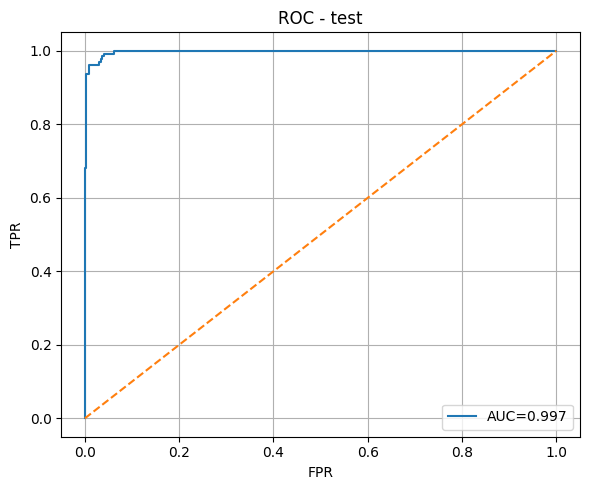

In [50]:
plot_eval_curves(
    y_true=y_test,
    probs=p_test,
    threshold=best_threshold,
    split_name="test",
    fig_dir=FIG_DIR,
    prefix="fase1"
)

## 7.6) GUARDAR MÉTRICAS TEST

In [51]:
test_summary = {
    "model_name": MODEL_NAME,
    "best_criterion": BEST_CRITERION,
    "best_epoch": int(best_epoch),
    "best_threshold": float(best_threshold),

    "test_loss": float(test_loss),
    "test_auc": float(test_eval["auc"]),
    "test_pr_auc": float(test_eval["pr_auc"]),

    "test_acc_05": float(m_test_05["acc"]),
    "test_f1_05": float(m_test_05["f1"]),
    "test_bacc_05": float(m_test_05["bacc"]),

    "test_acc_thr": float(m_test_thr["acc"]),
    "test_f1_thr": float(m_test_thr["f1"]),
    "test_bacc_thr": float(m_test_thr["bacc"]),
    "test_precision_thr": float(m_test_thr["precision"]),
    "test_sensitivity_thr": float(m_test_thr["sensitivity"]),
    "test_specificity_thr": float(m_test_thr["specificity"]),
    "test_pred1_thr": float(m_test_thr["pred1"]),

    "tn": int(m_test_thr["tn"]),
    "fp": int(m_test_thr["fp"]),
    "fn": int(m_test_thr["fn"]),
    "tp": int(m_test_thr["tp"]),
}

test_summary_path_json = os.path.join(
    LOG_DIR,
    "fase1_test_summary.json"
)

test_summary_path_csv = os.path.join(
    TABLE_DIR,
    "fase1_test_summary.csv"
)

with open(test_summary_path_json, "w", encoding="utf-8") as f:
    json.dump(
        test_summary,
        f,
        indent=2,
        ensure_ascii=False
    )

pd.DataFrame([test_summary]).to_csv(
    test_summary_path_csv,
    index=False
)

print("\n[Guardado]")
print(test_summary_path_json)
print(test_summary_path_csv)

print("\n[OK] Sección 7 terminada.")


[Guardado]
Results\MS_HQCNN\logs\fase1_test_summary.json
Results\MS_HQCNN\tables\fase1_test_summary.csv

[OK] Sección 7 terminada.


# **8) FASE 2: CONGELAR EXTRACTOR Y EXTRAER EMBEDDINGS z15**

## 8.1) CONGELAR MODELO

In [52]:
model.eval()

for p in model.parameters():
    p.requires_grad = False

print("=" * 70)
print("[FASE 2] Extracción de embeddings z15 - MS-HQCNN")
print("=" * 70)
print("[OK] Modelo congelado.")

[FASE 2] Extracción de embeddings z15 - MS-HQCNN
[OK] Modelo congelado.


## 8.2) FUNCIÓN DE EXTRACCIÓN

In [53]:
@torch.no_grad()
def extract_z15_from_loader(model, loader, device):

    model.eval()

    all_z = []
    all_y = []

    for xb, yb in loader:

        xb = xb.to(device, non_blocking=True).float()

        z15 = model.extract_features(xb)

        all_z.append(z15.detach().cpu().numpy())
        all_y.append(yb.detach().cpu().numpy())

    Z = np.concatenate(all_z, axis=0)
    y = np.concatenate(all_y, axis=0).astype(int)

    return Z, y

## 8.3) EXTRAER TRAIN / VAL / TEST

In [54]:
t0 = time.time()

Z_train, y_train = extract_z15_from_loader(model, train_loader, DEVICE)
Z_val, y_val     = extract_z15_from_loader(model, val_loader, DEVICE)
Z_test, y_test   = extract_z15_from_loader(model, test_loader, DEVICE)

dt = time.time() - t0

print("\n[Embeddings extraídos]")
print("Z_train:", Z_train.shape, "| y_train:", y_train.shape)
print("Z_val  :", Z_val.shape,   "| y_val  :", y_val.shape)
print("Z_test :", Z_test.shape,  "| y_test :", y_test.shape)
print(f"Tiempo extracción: {dt/60:.2f} min")


[Embeddings extraídos]
Z_train: (3641, 15) | y_train: (3641,)
Z_val  : (455, 15) | y_val  : (455,)
Z_test : (456, 15) | y_test : (456,)
Tiempo extracción: 5.50 min


## 8.4) VERIFICACIÓN DE DIMENSIÓN

In [55]:
assert Z_train.shape[1] == LATENT_DIM
assert Z_val.shape[1] == LATENT_DIM
assert Z_test.shape[1] == LATENT_DIM

print("\n[OK] Todos los embeddings tienen dimensión:", LATENT_DIM)


[OK] Todos los embeddings tienen dimensión: 15


## 8.5) CONVERTIR A DATAFRAMES

In [56]:
z_cols = [f"z{i+1}" for i in range(LATENT_DIM)]

df_train_z15 = pd.DataFrame(Z_train, columns=z_cols)
df_train_z15["target"] = y_train

df_val_z15 = pd.DataFrame(Z_val, columns=z_cols)
df_val_z15["target"] = y_val

df_test_z15 = pd.DataFrame(Z_test, columns=z_cols)
df_test_z15["target"] = y_test

print("\n[Preview train embeddings]")
display(df_train_z15.head())


[Preview train embeddings]


,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10,z11,z12,z13,z14,z15,target
0,-0.296870,-0.504447,0.366910,0.397464,-0.668972,-0.541146,0.467784,0.461518,-0.520711,0.372351,-0.619232,0.460108,0.495191,0.448130,-0.683778,0
1,-1.122647,-1.407515,1.264461,1.218281,-1.723939,-1.346710,1.435090,1.239314,-1.435885,1.224748,-1.508825,1.237292,1.358250,1.318343,-1.615801,0
2,0.519331,0.462416,-0.544397,-0.474799,0.374471,0.356146,-0.627471,-0.396743,0.405696,-0.561599,0.341091,-0.347364,-0.395613,-0.445648,0.212649,1
3,0.782227,0.799215,-0.827753,-0.782898,0.721237,0.694880,-0.987525,-0.721783,0.726177,-0.891127,0.657377,-0.624679,-0.705853,-0.751930,0.526708,1
4,-1.212235,-1.512638,1.350899,1.311328,-1.831598,-1.428015,1.532972,1.321574,-1.526027,1.317333,-1.602775,1.328999,1.444700,1.411514,-1.714704,0


## 8.6) GUARDAR CSV

In [57]:
train_csv = os.path.join(EMB_DIR, "train_z15.csv")
val_csv   = os.path.join(EMB_DIR, "val_z15.csv")
test_csv  = os.path.join(EMB_DIR, "test_z15.csv")

df_train_z15.to_csv(train_csv, index=False)
df_val_z15.to_csv(val_csv, index=False)
df_test_z15.to_csv(test_csv, index=False)

print("\n[Embeddings guardados]")
print(train_csv)
print(val_csv)
print(test_csv)


[Embeddings guardados]
Results\MS_HQCNN\embeddings\train_z15.csv
Results\MS_HQCNN\embeddings\val_z15.csv
Results\MS_HQCNN\embeddings\test_z15.csv


## 8.7) GUARDAR TAMBIÉN EN NPZ

In [58]:
npz_path = os.path.join(EMB_DIR, "embeddings_z15.npz")

np.savez(
    npz_path,
    Z_train=Z_train,
    y_train=y_train,
    Z_val=Z_val,
    y_val=y_val,
    Z_test=Z_test,
    y_test=y_test,
)

print("\n[NPZ guardado]")
print(npz_path)

print("\n[OK] Sección 8 terminada.")


[NPZ guardado]
Results\MS_HQCNN\embeddings\embeddings_z15.npz

[OK] Sección 8 terminada.


## **9) FASE 3: CLASIFICADOR AUXILIAR COMÚN SVM**
    z15 -> SVM binaria

In [59]:
from sklearn.svm import SVC

## 9.1) RESUMEN

In [60]:
print("=" * 70)
print("[FASE 3] Clasificador auxiliar común: SVM sobre z15")
print("=" * 70)

print("Z_train:", Z_train.shape, "| y_train:", y_train.shape)
print("Z_val  :", Z_val.shape,   "| y_val  :", y_val.shape)
print("Z_test :", Z_test.shape,  "| y_test :", y_test.shape)

assert Z_train.shape[1] == LATENT_DIM
assert Z_val.shape[1] == LATENT_DIM
assert Z_test.shape[1] == LATENT_DIM

[FASE 3] Clasificador auxiliar común: SVM sobre z15
Z_train: (3641, 15) | y_train: (3641,)
Z_val  : (455, 15) | y_val  : (455,)
Z_test : (456, 15) | y_test : (456,)


## 9.2) DEFINIR SVM AUXILIAR

In [61]:
aux_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        class_weight="balanced",
        random_state=SEED
    ))
])

print("\n[Modelo auxiliar]")
print(aux_model)


[Modelo auxiliar]
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])


## 9.3) ENTRENAR SVM

In [62]:
t0 = time.time()

aux_model.fit(
    Z_train,
    y_train
)

dt = time.time() - t0

print(f"\nTiempo entrenamiento SVM: {dt:.2f} s")


Tiempo entrenamiento SVM: 0.45 s


## 9.4) VALIDACIÓN: ELEGIR THRESHOLD

In [63]:
val_probs = aux_model.predict_proba(Z_val)[:, 1]

val_eval_aux = evaluate_binary_outputs(
    y_true=y_val,
    logits_or_probs=val_probs,
    from_logits=False
)

thr_aux = val_eval_aux["thr_star"]

print("\n" + "=" * 70)
print("[VALIDACIÓN AUXILIAR SVM]")
print("=" * 70)
print(f"Val AUC      : {val_eval_aux['auc']:.4f}")
print(f"Val PR-AUC   : {val_eval_aux['pr_auc']:.4f}")
print(f"Val thr*     : {thr_aux:.4f}")
print("\nVal @0.5:")
print(val_eval_aux["m05"])
print("\nVal @thr*:")
print(val_eval_aux["mstar"])


[VALIDACIÓN AUXILIAR SVM]
Val AUC      : 0.9803
Val PR-AUC   : 0.9164
Val thr*     : 0.1890

Val @0.5:
{'threshold': 0.5, 'acc': 0.9604395604395605, 'f1': 0.9296875, 'precision': 0.9296875, 'bacc': 0.9510822821100866, 'sensitivity': 0.9296874999999928, 'specificity': 0.9724770642201804, 'pred1': 0.2813186813186813, 'tn': 318, 'fp': 9, 'fn': 9, 'tp': 119}

Val @thr*:
{'threshold': 0.18895907966535502, 'acc': 0.967032967032967, 'f1': 0.9425287356321839, 'precision': 0.924812030075188, 'bacc': 0.9651782301223188, 'sensitivity': 0.9609374999999926, 'specificity': 0.9694189602446452, 'pred1': 0.2923076923076923, 'tn': 317, 'fp': 10, 'fn': 5, 'tp': 123}


## 9.5) TEST FINAL SVM

In [64]:
test_probs = aux_model.predict_proba(Z_test)[:, 1]

test_eval_aux = evaluate_binary_outputs(
    y_true=y_test,
    logits_or_probs=test_probs,
    from_logits=False
)

test_metrics_05 = test_eval_aux["m05"]

test_metrics_thr = binary_metrics_from_probs(
    y_true=y_test,
    probs=test_probs,
    threshold=thr_aux
)

print("\n" + "=" * 70)
print("[TEST AUXILIAR SVM]")
print("=" * 70)

print(f"Test AUC      : {test_eval_aux['auc']:.4f}")
print(f"Test PR-AUC   : {test_eval_aux['pr_auc']:.4f}")

print("\nTest @0.5:")
print(test_metrics_05)

print(f"\nTest @thr* val = {thr_aux:.4f}:")
print(test_metrics_thr)


[TEST AUXILIAR SVM]
Test AUC      : 0.9936
Test PR-AUC   : 0.9771

Test @0.5:
{'threshold': 0.5, 'acc': 0.9802631578947368, 'f1': 0.9647058823529412, 'precision': 0.968503937007874, 'bacc': 0.9743711890243849, 'sensitivity': 0.9609374999999926, 'specificity': 0.9878048780487774, 'pred1': 0.27850877192982454, 'tn': 324, 'fp': 4, 'fn': 5, 'tp': 123}

Test @thr* val = 0.1890:
{'threshold': 0.18895907966535502, 'acc': 0.9736842105263158, 'f1': 0.9534883720930233, 'precision': 0.9461538461538461, 'bacc': 0.9697980182926778, 'sensitivity': 0.9609374999999926, 'specificity': 0.9786585365853628, 'pred1': 0.2850877192982456, 'tn': 321, 'fp': 7, 'fn': 5, 'tp': 123}


## 9.6) MATRIZ DE CONFUSIÓN Y REPORTE

In [65]:
y_pred_test_aux = (test_probs >= thr_aux).astype(int)

cm_aux = confusion_matrix(
    y_test,
    y_pred_test_aux,
    labels=[0, 1]
)

print("\n[Confusion Matrix TEST - SVM z15]")
print(cm_aux)

print("\n[Classification Report TEST - SVM z15]")
print(
    classification_report(
        y_test,
        y_pred_test_aux,
        target_names=["Normal", "COVID"],
        digits=4,
        zero_division=0
    )
)


[Confusion Matrix TEST - SVM z15]
[[321   7]
 [  5 123]]

[Classification Report TEST - SVM z15]
              precision    recall  f1-score   support

      Normal     0.9847    0.9787    0.9817       328
       COVID     0.9462    0.9609    0.9535       128

    accuracy                         0.9737       456
   macro avg     0.9654    0.9698    0.9676       456
weighted avg     0.9739    0.9737    0.9737       456



## 9.7) GUARDAR RESULTADOS

In [66]:
aux_results = {
    "experiment_name": EXPERIMENT_NAME,
    "model_name": MODEL_NAME,
    "aux_classifier": "SVM_RBF",
    "features": int(LATENT_DIM),

    "svm_kernel": "rbf",
    "svm_C": 1.0,
    "svm_gamma": "scale",
    "svm_class_weight": "balanced",

    "val_auc": float(val_eval_aux["auc"]),
    "val_pr_auc": float(val_eval_aux["pr_auc"]),
    "val_threshold_star": float(thr_aux),
    "val_acc_thr": float(val_eval_aux["mstar"]["acc"]),
    "val_f1_thr": float(val_eval_aux["mstar"]["f1"]),
    "val_bacc_thr": float(val_eval_aux["mstar"]["bacc"]),

    "test_auc": float(test_eval_aux["auc"]),
    "test_pr_auc": float(test_eval_aux["pr_auc"]),

    "test_acc_05": float(test_metrics_05["acc"]),
    "test_f1_05": float(test_metrics_05["f1"]),
    "test_bacc_05": float(test_metrics_05["bacc"]),

    "test_acc_thr": float(test_metrics_thr["acc"]),
    "test_f1_thr": float(test_metrics_thr["f1"]),
    "test_precision_thr": float(test_metrics_thr["precision"]),
    "test_bacc_thr": float(test_metrics_thr["bacc"]),
    "test_sensitivity_thr": float(test_metrics_thr["sensitivity"]),
    "test_specificity_thr": float(test_metrics_thr["specificity"]),
    "test_pred1_thr": float(test_metrics_thr["pred1"]),

    "tn": int(test_metrics_thr["tn"]),
    "fp": int(test_metrics_thr["fp"]),
    "fn": int(test_metrics_thr["fn"]),
    "tp": int(test_metrics_thr["tp"]),
}

aux_json = os.path.join(
    LOG_DIR,
    "fase3_svm_z15_results.json"
)

aux_csv = os.path.join(
    TABLE_DIR,
    "fase3_svm_z15_results.csv"
)

with open(aux_json, "w", encoding="utf-8") as f:
    json.dump(
        aux_results,
        f,
        indent=2,
        ensure_ascii=False
    )

pd.DataFrame([aux_results]).to_csv(
    aux_csv,
    index=False
)

print("\n[Resultados SVM guardados]")
print(aux_json)
print(aux_csv)


[Resultados SVM guardados]
Results\MS_HQCNN\logs\fase3_svm_z15_results.json
Results\MS_HQCNN\tables\fase3_svm_z15_results.csv


## 9.8) GUARDAR PREDICCIONES TEST

In [67]:
pred_df = pd.DataFrame({
    "target": y_test,
    "prob_COVID": test_probs,
    "pred_thr": y_pred_test_aux,
})

pred_csv = os.path.join(
    TABLE_DIR,
    "fase3_svm_z15_test_predictions.csv"
)

pred_df.to_csv(
    pred_csv,
    index=False
)

print("\n[Predicciones TEST guardadas]")
print(pred_csv)


[Predicciones TEST guardadas]
Results\MS_HQCNN\tables\fase3_svm_z15_test_predictions.csv


## 9.9) TABLA RESUMEN

In [68]:
summary_svm_df = pd.DataFrame([
    {
        "Model": MODEL_NAME,
        "Embedding": "z15",
        "AuxClassifier": "SVM_RBF",
        "Test_AUC": test_eval_aux["auc"],
        "Test_PR_AUC": test_eval_aux["pr_auc"],
        "Test_ACC_thr": test_metrics_thr["acc"],
        "Test_F1_thr": test_metrics_thr["f1"],
        "Test_Precision_thr": test_metrics_thr["precision"],
        "Test_BACC_thr": test_metrics_thr["bacc"],
        "Threshold": thr_aux,
    }
])

display(summary_svm_df)

print("\n[OK] Sección 9 terminada: SVM auxiliar común entrenada sobre z15.")

,Model,Embedding,AuxClassifier,Test_AUC,Test_PR_AUC,Test_ACC_thr,Test_F1_thr,Test_Precision_thr,Test_BACC_thr,Threshold
0,MS-HQCNN-3,z15,SVM_RBF,0.993569,0.977148,0.973684,0.953488,0.946154,0.969798,0.188959



[OK] Sección 9 terminada: SVM auxiliar común entrenada sobre z15.


# **10) VISUALIZACIÓN DEL ESPACIO LATENTE z15**
     PCA 2D, PCA 3D

In [70]:
from sklearn.decomposition import PCA

## 10.1) UNIR TRAIN + VAL + TEST

In [71]:
Z_all = np.vstack([
    Z_train,
    Z_val,
    Z_test
])

y_all = np.concatenate([
    y_train,
    y_val,
    y_test
])

print("=" * 70)
print("[Sección 10] PCA sobre embeddings z15")
print("=" * 70)

print("Z_all:", Z_all.shape)
print("y_all:", y_all.shape)

[Sección 10] PCA sobre embeddings z15
Z_all: (4552, 15)
y_all: (4552,)


## 10.2) PCA 2D


[PCA 2D]
Varianza explicada: 99.97% + 0.02% = 99.99%


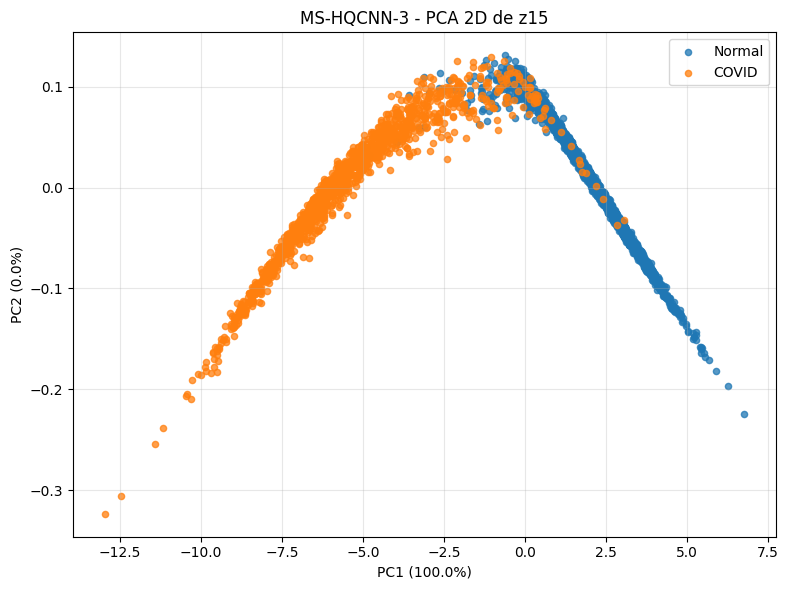

[Guardado] Results\MS_HQCNN\figures\z15_pca_2d.png


In [72]:
pca2 = PCA(
    n_components=2,
    random_state=SEED
)

Z_pca2 = pca2.fit_transform(Z_all)

var2 = pca2.explained_variance_ratio_

print("\n[PCA 2D]")
print(
    f"Varianza explicada: "
    f"{100*var2[0]:.2f}% + "
    f"{100*var2[1]:.2f}% = "
    f"{100*np.sum(var2):.2f}%"
)

plt.figure(figsize=(8, 6))

for cls, label in [
    (0, "Normal"),
    (1, "COVID")
]:

    mask = y_all == cls

    plt.scatter(
        Z_pca2[mask, 0],
        Z_pca2[mask, 1],
        s=20,
        alpha=0.75,
        label=label
    )

plt.xlabel(
    f"PC1 ({100*var2[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*var2[1]:.1f}%)"
)

plt.title(
    f"{MODEL_NAME} - PCA 2D de z15"
)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

pca2_path = os.path.join(
    FIG_DIR,
    "z15_pca_2d.png"
)

plt.savefig(
    pca2_path,
    dpi=200
)

plt.show()

print("[Guardado]", pca2_path)

## 10.3) PCA 3D


[PCA 3D]
Varianza explicada acumulada: 100.00%


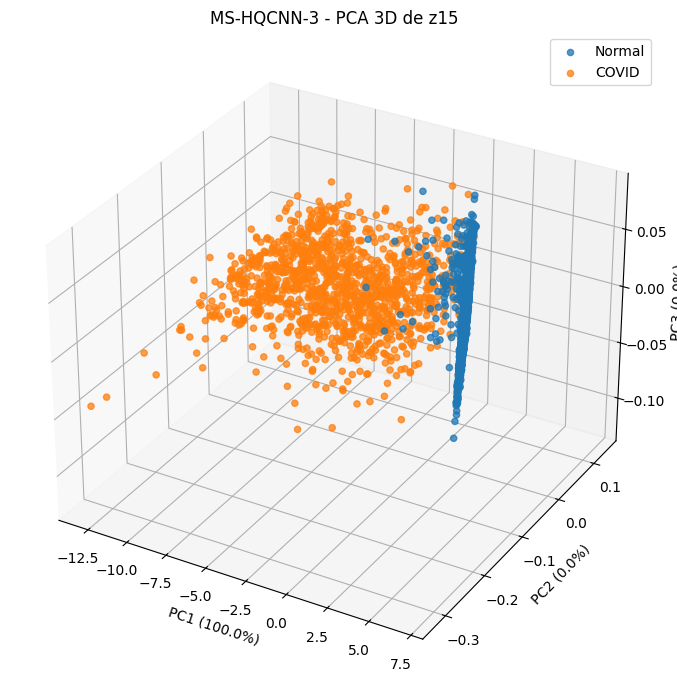

[Guardado] Results\MS_HQCNN\figures\z15_pca_3d.png


In [73]:
pca3 = PCA(
    n_components=3,
    random_state=SEED
)

Z_pca3 = pca3.fit_transform(Z_all)

var3 = pca3.explained_variance_ratio_

print("\n[PCA 3D]")
print(
    f"Varianza explicada acumulada: "
    f"{100*np.sum(var3):.2f}%"
)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(
    111,
    projection="3d"
)

for cls, label in [
    (0, "Normal"),
    (1, "COVID")
]:

    mask = y_all == cls

    ax.scatter(
        Z_pca3[mask, 0],
        Z_pca3[mask, 1],
        Z_pca3[mask, 2],
        s=20,
        alpha=0.75,
        label=label
    )

ax.set_xlabel(
    f"PC1 ({100*var3[0]:.1f}%)"
)

ax.set_ylabel(
    f"PC2 ({100*var3[1]:.1f}%)"
)

ax.set_zlabel(
    f"PC3 ({100*var3[2]:.1f}%)"
)

ax.set_title(
    f"{MODEL_NAME} - PCA 3D de z15"
)

ax.legend()

plt.tight_layout()

pca3_path = os.path.join(
    FIG_DIR,
    "z15_pca_3d.png"
)

plt.savefig(
    pca3_path,
    dpi=200
)

plt.show()

print("[Guardado]", pca3_path)

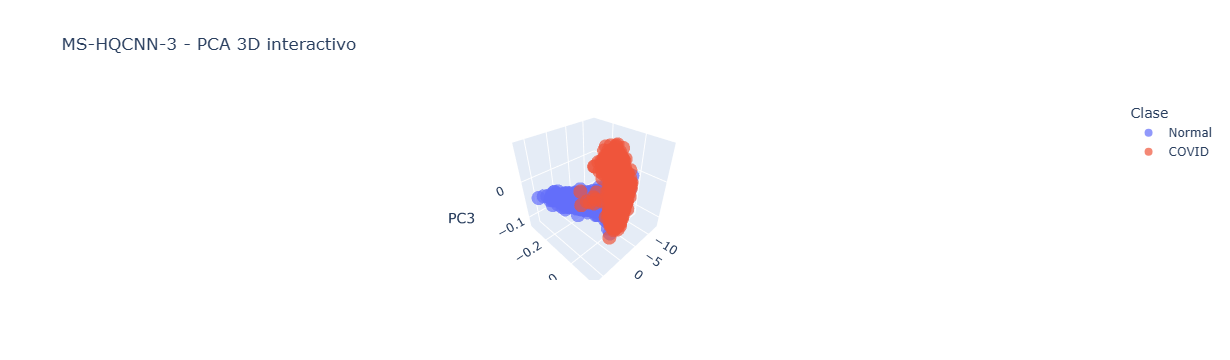

In [74]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "PC1": Z_pca3[:,0],
    "PC2": Z_pca3[:,1],
    "PC3": Z_pca3[:,2],
    "Clase": np.where(y_all == 1, "COVID", "Normal")
})

fig = px.scatter_3d(
    df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Clase",
    opacity=0.7,
    title=f"{MODEL_NAME} - PCA 3D interactivo"
)

fig.show()

# **11) ANÁLISIS DE RELEVANCIA DE FEATURES z15**

In [75]:
from sklearn.inspection import permutation_importance

## 11.1) CORRELATION MATRIX z15

[Sección 11] Relevancia de features z15

[Correlation Matrix z15]


,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10,z11,z12,z13,z14,z15
z1,1.000000,0.999862,-0.999883,-0.999867,0.999841,0.999412,-0.999250,-0.999441,0.999926,-0.999601,0.999798,-0.999817,-0.999908,-0.999943,0.999853
z2,0.999862,1.000000,-0.999830,-0.999945,0.999595,0.999796,-0.999616,-0.999749,0.999880,-0.999865,0.999973,-0.999841,-0.999864,-0.999877,0.999646
z3,-0.999883,-0.999830,1.000000,0.999926,-0.999715,-0.999459,0.999533,0.999668,-0.999816,0.999758,-0.999841,0.999920,0.999868,0.999927,-0.999715
z4,-0.999867,-0.999945,0.999926,1.000000,-0.999640,-0.999692,0.999626,0.999788,-0.999868,0.999868,-0.999934,0.999885,0.999906,0.999930,-0.999689
z5,0.999841,0.999595,-0.999715,-0.999640,1.000000,0.998921,-0.998708,-0.999005,0.999851,-0.999194,0.999473,-0.999552,-0.999841,-0.999847,0.999977
z6,0.999412,0.999796,-0.999459,-0.999692,0.998921,1.000000,-0.999811,-0.999818,0.999518,-0.999860,0.999844,-0.999567,-0.999481,-0.999472,0.999018
z7,-0.999250,-0.999616,0.999533,0.999626,-0.998708,-0.999811,1.000000,0.999937,-0.999250,0.999910,-0.999764,0.999663,0.999329,0.999386,-0.998775
z8,-0.999441,-0.999749,0.999668,0.999788,-0.999005,-0.999818,0.999937,1.000000,-0.999457,0.999970,-0.999854,0.999774,0.999563,0.999605,-0.999096
z9,0.999926,0.999880,-0.999816,-0.999868,0.999851,0.999518,-0.999250,-0.999457,1.000000,-0.999600,0.999807,-0.999725,-0.999942,-0.999932,0.999886
z10,-0.999601,-0.999865,0.999758,0.999868,-0.999194,-0.999860,0.999910,0.999970,-0.999600,1.000000,-0.999940,0.999846,0.999682,0.999712,-0.999266


[Guardado] Results\MS_HQCNN\tables\z15_correlation_matrix.csv


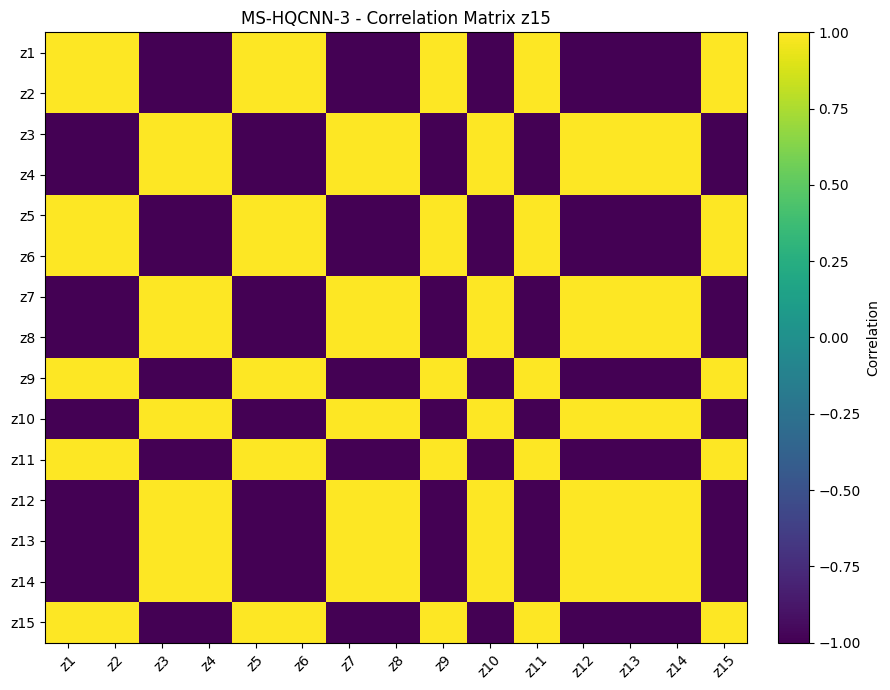

[Guardado] Results\MS_HQCNN\figures\z15_correlation_matrix.png


In [76]:
print("=" * 70)
print("[Sección 11] Relevancia de features z15")
print("=" * 70)

z_cols = [f"z{i+1}" for i in range(LATENT_DIM)]

# Usamos todos los embeddings para estudiar estructura global
Z_all = np.vstack([
    Z_train,
    Z_val,
    Z_test
])

y_all = np.concatenate([
    y_train,
    y_val,
    y_test
])

df_z_all = pd.DataFrame(
    Z_all,
    columns=z_cols
)

df_z_all["target"] = y_all

corr_z = df_z_all[z_cols].corr()

print("\n[Correlation Matrix z15]")
display(corr_z)

corr_csv = os.path.join(
    TABLE_DIR,
    "z15_correlation_matrix.csv"
)

corr_z.to_csv(
    corr_csv,
    index=True
)

print("[Guardado]", corr_csv)


# -------------------------------
# Heatmap de correlaciones
# -------------------------------

plt.figure(figsize=(9, 7))

im = plt.imshow(
    corr_z.values,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(
    im,
    fraction=0.046,
    pad=0.04,
    label="Correlation"
)

plt.xticks(
    ticks=np.arange(LATENT_DIM),
    labels=z_cols,
    rotation=45
)

plt.yticks(
    ticks=np.arange(LATENT_DIM),
    labels=z_cols
)

plt.title(
    f"{MODEL_NAME} - Correlation Matrix z15"
)

plt.tight_layout()

corr_fig = os.path.join(
    FIG_DIR,
    "z15_correlation_matrix.png"
)

plt.savefig(
    corr_fig,
    dpi=200
)

plt.show()

print("[Guardado]", corr_fig)

## 11.2) PERMUTATION IMPORTANCE USANDO LA SVM

In [77]:
print("\n" + "=" * 70)
print("[Permutation Importance] SVM sobre z15")
print("=" * 70)

perm_t0 = time.time()

perm_result = permutation_importance(
    estimator=aux_model,
    X=Z_test,
    y=y_test,
    scoring="accuracy",
    n_repeats=30,
    random_state=SEED,
    n_jobs=1
)

perm_dt = time.time() - perm_t0

print(f"Tiempo permutation importance: {perm_dt:.2f} s")

importance_mean = perm_result.importances_mean
importance_std = perm_result.importances_std

importance_df = pd.DataFrame({
    "feature": z_cols,
    "importance_mean": importance_mean,
    "importance_std": importance_std
})

importance_df["importance_abs"] = importance_df["importance_mean"].abs()

importance_df = importance_df.sort_values(
    by="importance_mean",
    ascending=False
).reset_index(drop=True)

print("\n[Permutation Importance - Ranking]")
display(importance_df)


[Permutation Importance] SVM sobre z15
Tiempo permutation importance: 6.51 s

[Permutation Importance - Ranking]


,feature,importance_mean,importance_std,importance_abs
0,z4,-0.001608,0.003200,0.001608
1,z12,-0.001754,0.003272,0.001754
2,z10,-0.001974,0.003068,0.001974
3,z3,-0.001974,0.002290,0.001974
4,z2,-0.002047,0.002993,0.002047
5,z6,-0.002047,0.002591,0.002047
6,z8,-0.002120,0.002744,0.002120
7,z13,-0.002120,0.002155,0.002120
8,z7,-0.002193,0.002887,0.002193
9,z11,-0.002266,0.002368,0.002266


## 11.3) RANKING DE FEATURES

In [78]:
ranking_csv = os.path.join(
    TABLE_DIR,
    "z15_svm_permutation_importance.csv"
)

importance_df.to_csv(
    ranking_csv,
    index=False
)

print("[Guardado]", ranking_csv)

print("\n[Top features]")
display(importance_df.head(10))

print("\n[Features con importancia cercana a cero o negativa]")
display(
    importance_df[
        importance_df["importance_mean"] <= 0
    ]
)

[Guardado] Results\MS_HQCNN\tables\z15_svm_permutation_importance.csv

[Top features]


,feature,importance_mean,importance_std,importance_abs
0,z4,-0.001608,0.003200,0.001608
1,z12,-0.001754,0.003272,0.001754
2,z10,-0.001974,0.003068,0.001974
3,z3,-0.001974,0.002290,0.001974
4,z2,-0.002047,0.002993,0.002047
5,z6,-0.002047,0.002591,0.002047
6,z8,-0.002120,0.002744,0.002120
7,z13,-0.002120,0.002155,0.002120
8,z7,-0.002193,0.002887,0.002193
9,z11,-0.002266,0.002368,0.002266



[Features con importancia cercana a cero o negativa]


,feature,importance_mean,importance_std,importance_abs
0,z4,-0.001608,0.003200,0.001608
1,z12,-0.001754,0.003272,0.001754
2,z10,-0.001974,0.003068,0.001974
3,z3,-0.001974,0.002290,0.001974
4,z2,-0.002047,0.002993,0.002047
5,z6,-0.002047,0.002591,0.002047
6,z8,-0.002120,0.002744,0.002120
7,z13,-0.002120,0.002155,0.002120
8,z7,-0.002193,0.002887,0.002193
9,z11,-0.002266,0.002368,0.002266


## 11.4) BARPLOT DE IMPORTANCIA

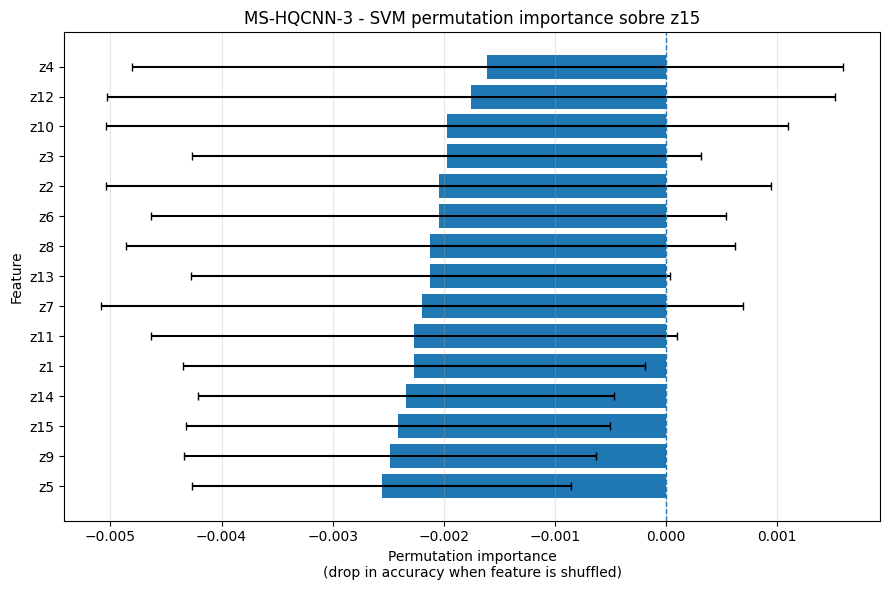

[Guardado] Results\MS_HQCNN\figures\z15_svm_permutation_importance.png


In [79]:
plot_df = importance_df.sort_values(
    by="importance_mean",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"],
    capsize=3
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Permutation importance\n(drop in accuracy when feature is shuffled)"
)

plt.ylabel(
    "Feature"
)

plt.title(
    f"{MODEL_NAME} - SVM permutation importance sobre z15"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

importance_fig = os.path.join(
    FIG_DIR,
    "z15_svm_permutation_importance.png"
)

plt.savefig(
    importance_fig,
    dpi=200
)

plt.show()

print("[Guardado]", importance_fig)

## 11.5) IMPORTANCIA RELATIVA NORMALIZADA


[Importancia relativa]


,feature,importance_mean,importance_std,importance_abs,importance_clipped,relative_importance
0,z4,-0.001608,0.003200,0.001608,0.0,0.0
1,z12,-0.001754,0.003272,0.001754,0.0,0.0
2,z10,-0.001974,0.003068,0.001974,0.0,0.0
3,z3,-0.001974,0.002290,0.001974,0.0,0.0
4,z2,-0.002047,0.002993,0.002047,0.0,0.0
5,z6,-0.002047,0.002591,0.002047,0.0,0.0
6,z8,-0.002120,0.002744,0.002120,0.0,0.0
7,z13,-0.002120,0.002155,0.002120,0.0,0.0
8,z7,-0.002193,0.002887,0.002193,0.0,0.0
9,z11,-0.002266,0.002368,0.002266,0.0,0.0


[Guardado] Results\MS_HQCNN\tables\z15_svm_relative_importance.csv


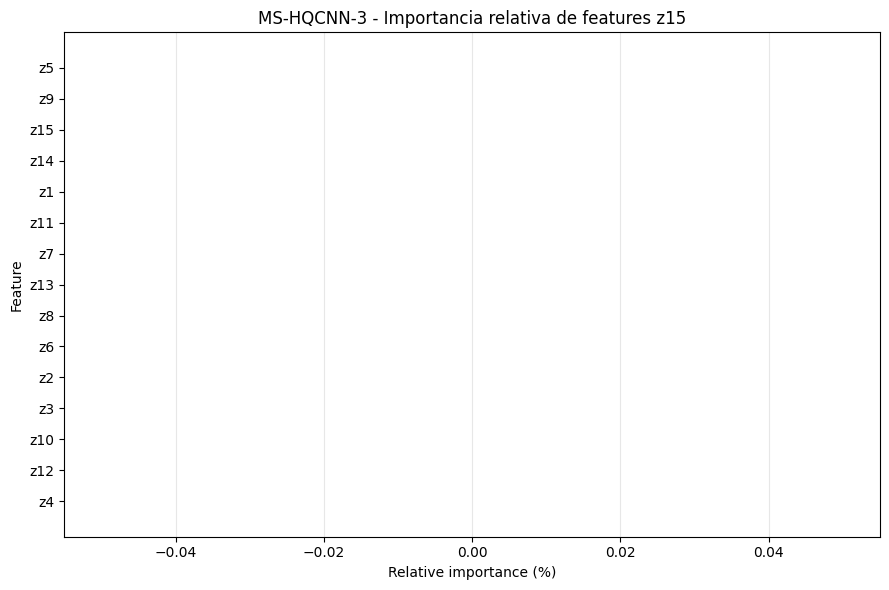

[Guardado] Results\MS_HQCNN\figures\z15_svm_relative_importance.png


In [80]:
importance_positive = importance_df.copy()

importance_positive["importance_clipped"] = importance_positive[
    "importance_mean"
].clip(lower=0)

total_importance = importance_positive[
    "importance_clipped"
].sum()

if total_importance > 0:

    importance_positive["relative_importance"] = (
        importance_positive["importance_clipped"]
        / total_importance
    )

else:

    importance_positive["relative_importance"] = 0.0

relative_csv = os.path.join(
    TABLE_DIR,
    "z15_svm_relative_importance.csv"
)

importance_positive.to_csv(
    relative_csv,
    index=False
)

print("\n[Importancia relativa]")
display(importance_positive)

print("[Guardado]", relative_csv)


# -------------------------------
# Barplot importancia relativa
# -------------------------------

rel_plot_df = importance_positive.sort_values(
    by="relative_importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    rel_plot_df["feature"],
    100 * rel_plot_df["relative_importance"]
)

plt.xlabel(
    "Relative importance (%)"
)

plt.ylabel(
    "Feature"
)

plt.title(
    f"{MODEL_NAME} - Importancia relativa de features z15"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

relative_fig = os.path.join(
    FIG_DIR,
    "z15_svm_relative_importance.png"
)

plt.savefig(
    relative_fig,
    dpi=200
)

plt.show()

print("[Guardado]", relative_fig)

## 11.6) RESUMEN FINAL

In [81]:
top_feature = importance_df.iloc[0]["feature"]
top_importance = importance_df.iloc[0]["importance_mean"]

summary_feature_importance = {
    "model_name": MODEL_NAME,
    "method": "SVM permutation importance",
    "scoring": "accuracy",
    "n_repeats": 30,
    "top_feature": str(top_feature),
    "top_importance_mean": float(top_importance),
    "num_features": int(LATENT_DIM),
    "correlation_matrix_csv": corr_csv,
    "importance_csv": ranking_csv,
    "relative_importance_csv": relative_csv,
}

summary_path = os.path.join(
    LOG_DIR,
    "z15_feature_importance_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary_feature_importance,
        f,
        indent=2,
        ensure_ascii=False
    )

print("\n" + "=" * 70)
print("[OK] Sección 11 terminada")
print("=" * 70)
print("Top feature:", top_feature)
print("Top importance:", top_importance)
print("Summary:", summary_path)


[OK] Sección 11 terminada
Top feature: z4
Top importance: -0.0016081871345029438
Summary: Results\MS_HQCNN\logs\z15_feature_importance_summary.json
